In [1]:
# Use ChromaDB for storing some vectors
# see https://docs.trychroma.com/guides
# - embedding
# - similarity / distance function
# - metadata
# - collections

In [1]:
import chromadb
# setup Chroma in-memory, for easy prototyping. Can add persistence easily!
client = chromadb.Client()

# client = chromadb.PersistentClient(path="/path/to/save/to")

In [2]:
from chromadb.utils import embedding_functions
embed_fn = embedding_functions.DefaultEmbeddingFunction()
embed_fn

In [3]:
dir(embedding_functions)

['AmazonBedrockEmbeddingFunction',
 'Any',
 'BasetenEmbeddingFunction',
 'Bm25EmbeddingFunction',
 'ChromaBm25EmbeddingFunction',
 'ChromaCloudQwenEmbeddingFunction',
 'ChromaCloudSpladeEmbeddingFunction',
 'ChromaLangchainEmbeddingFunction',
 'CloudflareWorkersAIEmbeddingFunction',
 'CohereEmbeddingFunction',
 'DefaultEmbeddingFunction',
 'Dict',
 'EmbeddingFunction',
 'FastembedSparseEmbeddingFunction',
 'GoogleGenaiEmbeddingFunction',
 'GoogleGenerativeAiEmbeddingFunction',
 'GooglePalmEmbeddingFunction',
 'GoogleVertexEmbeddingFunction',
 'HuggingFaceEmbeddingFunction',
 'HuggingFaceEmbeddingServer',
 'HuggingFaceSparseEmbeddingFunction',
 'InstructorEmbeddingFunction',
 'JinaEmbeddingFunction',
 'JinaQueryConfig',
 'MistralEmbeddingFunction',
 'MorphEmbeddingFunction',
 'NomicEmbeddingFunction',
 'NomicQueryConfig',
 'ONNXMiniLM_L6_V2',
 'OllamaEmbeddingFunction',
 'OpenAIEmbeddingFunction',
 'OpenCLIPEmbeddingFunction',
 'RoboflowEmbeddingFunction',
 'SentenceTransformerEmbedding

In [4]:
dir(embed_fn)

['__abstractmethods__',
 '__annotations__',
 '__call__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__non_callable_proto_members__',
 '__orig_bases__',
 '__parameters__',
 '__protocol_attrs__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_is_protocol',
 '_is_runtime_protocol',
 'build_from_config',
 'default_space',
 'embed_query',
 'embed_with_retries',
 'get_config',
 'is_legacy',
 'max_tokens',
 'name',
 'supported_spaces',
 'validate_config',
 'validate_config_update']

In [5]:
embed_fn.max_tokens()

256

In [6]:
inf_chunk_1 = """A vector database, vector store or vector search engine is a database that can store vectors 
(fixed-length lists of numbers) along with other data items. Vector databases typically implement one or more 
Approximate Nearest Neighbor algorithms,so that one can search the database with a query vector to retrieve the 
closest matching database records."""

inf_chunk_2 = """Vectors are mathematical representations of data in a high-dimensional space. In this space, 
each dimension corresponds to a feature of the data, with the number of dimensions ranging from a few hundred to 
tens of thousands, depending on the complexity of the data being represented. A vector's position in this space 
represents its characteristics. Words, phrases, or entire documents, as well as images, audio, and other types of data, 
can all be vectorized."""

inf_chunk_3 = """The Moon is Earth's only natural satellite. It orbits at an average distance of 384,400 km (238,900 mi), 
about 30 times the diameter of Earth. Tidal forces between Earth and the Moon have synchronized the Moon's orbital period 
(lunar month) with its rotation period (lunar day) at 29.5 Earth days, causing the same side of the Moon to always face Earth.  
"""

vectors = embed_fn([inf_chunk_1]) 
print(type(vectors))              # the embedding function returns a list of vectors  
print(type(vectors[0]))           # each vector is a numpy array
print(vectors[0].shape)           # of shape (384,) 

<class 'list'>
<class 'numpy.ndarray'>
(384,)


In [8]:
############### Similarity between two vectors is measured by Cosine Similarity ##################
import numpy as np

vector_1 = embed_fn([inf_chunk_1])[0]
vector_2 = embed_fn([inf_chunk_2])[0]
vector_3 = embed_fn([inf_chunk_3])[0]

def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    return  dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))


print("length of vector 1 :", np.linalg.norm(vector_1))              # the embedding function we used produces normed vectors
print("length of vector 2 :", np.linalg.norm(vector_2))              # therefore dot product and cosine similarity are the same
print("<vector 1,vector 2>:", np.dot(vector_1, vector_2))
print("cosine_similarity  :", cosine_similarity(vector_1, vector_2))
print("cosine_similarity  :", cosine_similarity(vector_1, vector_3))

# If your embedding function produces L2-normalized vectors (i.e., each vector has norm 1), 
# then Euclidean distance and cosine similarity are equivalent for ranking and nearest-neighbor search, 
# but they are not numerically identical.
print("Euclidian dist     :", np.linalg.norm(vector_1 - vector_2)) 

length of vector 1 : 1.0
length of vector 2 : 1.0
<vector 1,vector 2>: 0.68768364
cosine_similarity  : 0.68768364
cosine_similarity  : -0.008234379
Euclidian dist     : 0.7903371


In [9]:
vectors = [vector_1, vector_2, vector_3]

for i, v1 in enumerate(vectors):
    for j, v2 in enumerate(vectors):
        print(f"({i+1},{j+1})",cosine_similarity(v1, v2), np.linalg.norm(v1 - v2))

(1,1) 1.0 0.0
(1,2) 0.68768364 0.7903371
(1,3) -0.008234379 1.4200242
(2,1) 0.68768364 0.7903371
(2,2) 1.0 0.0
(2,3) 0.019826533 1.400124
(3,1) -0.008234379 1.4200242
(3,2) 0.019826533 1.400124
(3,3) 1.0000001 0.0


In [10]:
# Create a collection
try:
    client.delete_collection(name="my_collection")
except Exception as e:
   print(e)
    
collection = client.create_collection(name="my_collection", 
                                      embedding_function=embed_fn, 
                                      metadata={"hnsw:space": "cosine"} # l2 is the default
                                     )
collection = client.get_collection(name="my_collection", embedding_function=embed_fn)

Collection [my_collection] does not exist


In [11]:
# Add documents and their metadata into the collection
import uuid

ids = []
for i  in range(3):
    ids.append(str(uuid.uuid4()))

collection.add(
    documents=[inf_chunk_1, inf_chunk_2, inf_chunk_3],
    metadatas=[
        {"wikipedia": "Vector database", "url": "https://en.wikipedia.org/wiki/Vector_database"}, 
        {"wikipedia": "Vector database", "url": "https://en.wikipedia.org/wiki/Vector_database"}, 
        {"wikipedia": "Moon", "url": "https://en.wikipedia.org/wiki/Moon"}],
    ids=ids
)

In [12]:
print(collection.count())

3


In [13]:
# Retrieval Step
question = "Tell me something about the moon."
question_embeddings = embed_fn([question])


result = collection.query(
    query_embeddings=question_embeddings,
    n_results=2,
)

In [15]:
result #distance = 1 - cosine_similarity !

{'ids': [['8cfc7742-a9f1-4fdd-b224-9638b82177ef',
   '9b417d9e-6aa4-4e48-b487-46482958d1dc']],
 'embeddings': None,
 'documents': [["The Moon is Earth's only natural satellite. It orbits at an average distance of 384,400 km (238,900 mi), \nabout 30 times the diameter of Earth. Tidal forces between Earth and the Moon have synchronized the Moon's orbital period \n(lunar month) with its rotation period (lunar day) at 29.5 Earth days, causing the same side of the Moon to always face Earth.  \n",
   "Vectors are mathematical representations of data in a high-dimensional space. In this space, \neach dimension corresponds to a feature of the data, with the number of dimensions ranging from a few hundred to \ntens of thousands, depending on the complexity of the data being represented. A vector's position in this space \nrepresents its characteristics. Words, phrases, or entire documents, as well as images, audio, and other types of data, \ncan all be vectorized."]],
 'uris': None,
 'included'

In [14]:
result = collection.query(
    query_embeddings=question_embeddings,
    n_results=2,
    where={"wikipedia": "Vector database"}
)

In [17]:
result

{'ids': [['9b417d9e-6aa4-4e48-b487-46482958d1dc',
   '4223f8f2-a987-4900-81bf-dcd04cebdbfa']],
 'embeddings': None,
 'documents': [["Vectors are mathematical representations of data in a high-dimensional space. In this space, \neach dimension corresponds to a feature of the data, with the number of dimensions ranging from a few hundred to \ntens of thousands, depending on the complexity of the data being represented. A vector's position in this space \nrepresents its characteristics. Words, phrases, or entire documents, as well as images, audio, and other types of data, \ncan all be vectorized.",
   'A vector database, vector store or vector search engine is a database that can store vectors \n(fixed-length lists of numbers) along with other data items. Vector databases typically implement one or more \nApproximate Nearest Neighbor algorithms,so that one can search the database with a query vector to retrieve the \nclosest matching database records.']],
 'uris': None,
 'included': ['me

In [17]:
!pip install scikit-learn matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [20]:
X = np.array(vectors)
X

array([[ 0.00463841,  0.01719825, -0.08346181, ..., -0.03139447,
         0.02235406, -0.03191802],
       [ 0.03821511, -0.04603226, -0.04857105, ...,  0.01965923,
        -0.01360183, -0.04481702],
       [ 0.10053617, -0.02677136,  0.05188435, ...,  0.01645201,
        -0.03207798,  0.0010037 ]], shape=(3, 384), dtype=float32)

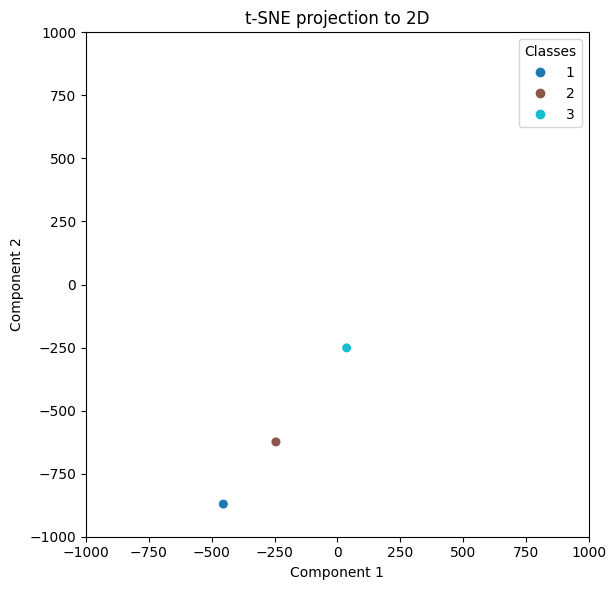

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


num_points = 100
dim = 50
X = np.array(vectors)
labels = [1,2,3]

# Run t-SNE to project into 2D
tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    perplexity=1,
    random_state=42,
)

X_2d = tsne.fit_transform(X)

# Plot the result
plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,
    s=30,
    cmap="tab10"
)
plt.title("t-SNE projection to 2D")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.tight_layout()
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)
plt.show()
